# 06e · GSE65391 · RNA_array · seven patient groups, rebuilt with the paper's method

Reads `pg_profiles.rds` (notebook 06d) and Table S2 of Banchereau et al. Writes `pg_paper_groups.csv`.

**The paper's step.** "Clustering of the interindividual SLEDAI correlation matrix identified seven
patient groups (PG1–7), each displaying a specific combination of five immune signatures correlating
with the SLEDAI" (Banchereau R et al. *Cell* 2016;165:551–565).

**What the paper states, and what it does not.**
- Stated: the profile (each child's SLEDAI correlations with the 797 transcripts), the distance used to
  place new patients into the groups, 1 − Pearson r (supplementary methods), and the number of groups, 7.
- Not stated: the linkage, and how seven was chosen.

**Choices made here where the paper is silent.**
- Distance: 1 − Pearson r between children's 797-probe profiles, the paper's own distance.
- Linkage: average linkage (UPGMA), the linkage used with correlation distance for expression profiles
  since Eisen MB, Spellman PT, Brown PO, Botstein D. Cluster analysis and display of genome-wide
  expression patterns. *PNAS* 1998;95:14863–14868, doi:10.1073/pnas.95.25.14863. **This is our choice,
  not the paper's.**
- The tree is cut into 7 groups **only because the paper did**, to compare with its Table S2. Whether 7
  groups are supported by the data is tested in notebooks 06f (gap statistic) and 06g (pvclust).

**Tests of agreement with the paper.**
1. Group sizes, largest to smallest, against Table S2 (PG1–7: 13, 17, 10, 16, 11, 9, 4).
2. Each group's mean profile over the five networks: does each group show "a specific combination of
   five immune signatures"?

In [1]:
source("../src/paths.R")
suppressMessages({library(ComplexHeatmap); library(circlize)})
pg <- readRDS(art("GSE65391", "pg_profiles.rds"))
r <- pg$r797[, colSums(is.na(pg$r797)) == 0]       # probes with an r in every child
c(children = nrow(r), probes_used = ncol(r))
hc <- hclust(as.dist(1 - cor(t(r))), method = "average")
groups <- cutree(hc, k = 7)
paper_sizes <- c(PG1 = 13, PG2 = 17, PG3 = 10, PG4 = 16, PG5 = 11, PG6 = 9, PG7 = 4)
list(rebuilt_sizes_sorted = sort(as.integer(table(groups)), decreasing = TRUE),
     paper_sizes_sorted = sort(unname(paper_sizes), decreasing = TRUE))

children probes_used 
         83         713

$rebuilt_sizes_sorted
[1] 34 29 13  3  2  1  1

$paper_sizes_sorted
[1] 17 16 13 11 10  9  4

**Result: the paper's group sizes are not reproduced.** 713 of the 797 probes have an r in every child.
Cut at seven, the tree gives groups of 34, 29, 13, 3, 2, 1 and 1 children; the paper's are 17, 16, 13, 11,
10, 9 and 4. Three groups hold 76 of the 83 children, and the other four are one to three children each.

In [2]:
profile <- round(aggregate(pg$net5, list(group = groups), mean), 2)
profile$children <- as.integer(table(groups)[as.character(profile$group)])
profile

group,ER,IFN,ML,PC,LL,children
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,-0.24,0.24,0.21,0.12,-0.07,13
2,-0.14,-0.06,-0.18,0.42,0.28,29
3,0.12,0.17,0.19,-0.20,-0.27,34
4,-0.07,0.20,-0.05,0.05,0.00,2
5,0.24,0.38,-0.07,0.26,0.09,3
6,-0.05,-0.22,0.03,0.31,-0.02,1
7,0.00,-0.16,-0.06,0.02,-0.03,1


**Result.** The three large groups differ in which networks follow SLEDAI:
- group 3 (34 children): erythropoiesis, interferon and myeloid rise with SLEDAI; plasma cell and lymphoid fall;
- group 2 (29): plasma cell and lymphoid rise; the others fall;
- group 1 (13): interferon and myeloid rise; erythropoiesis falls.

These are combinations of the paper's five signatures, as the paper describes, but in three large groups,
not seven of similar size. The paper does not give its linkage; with average linkage, which is our
choice, its seven groups are not recovered.

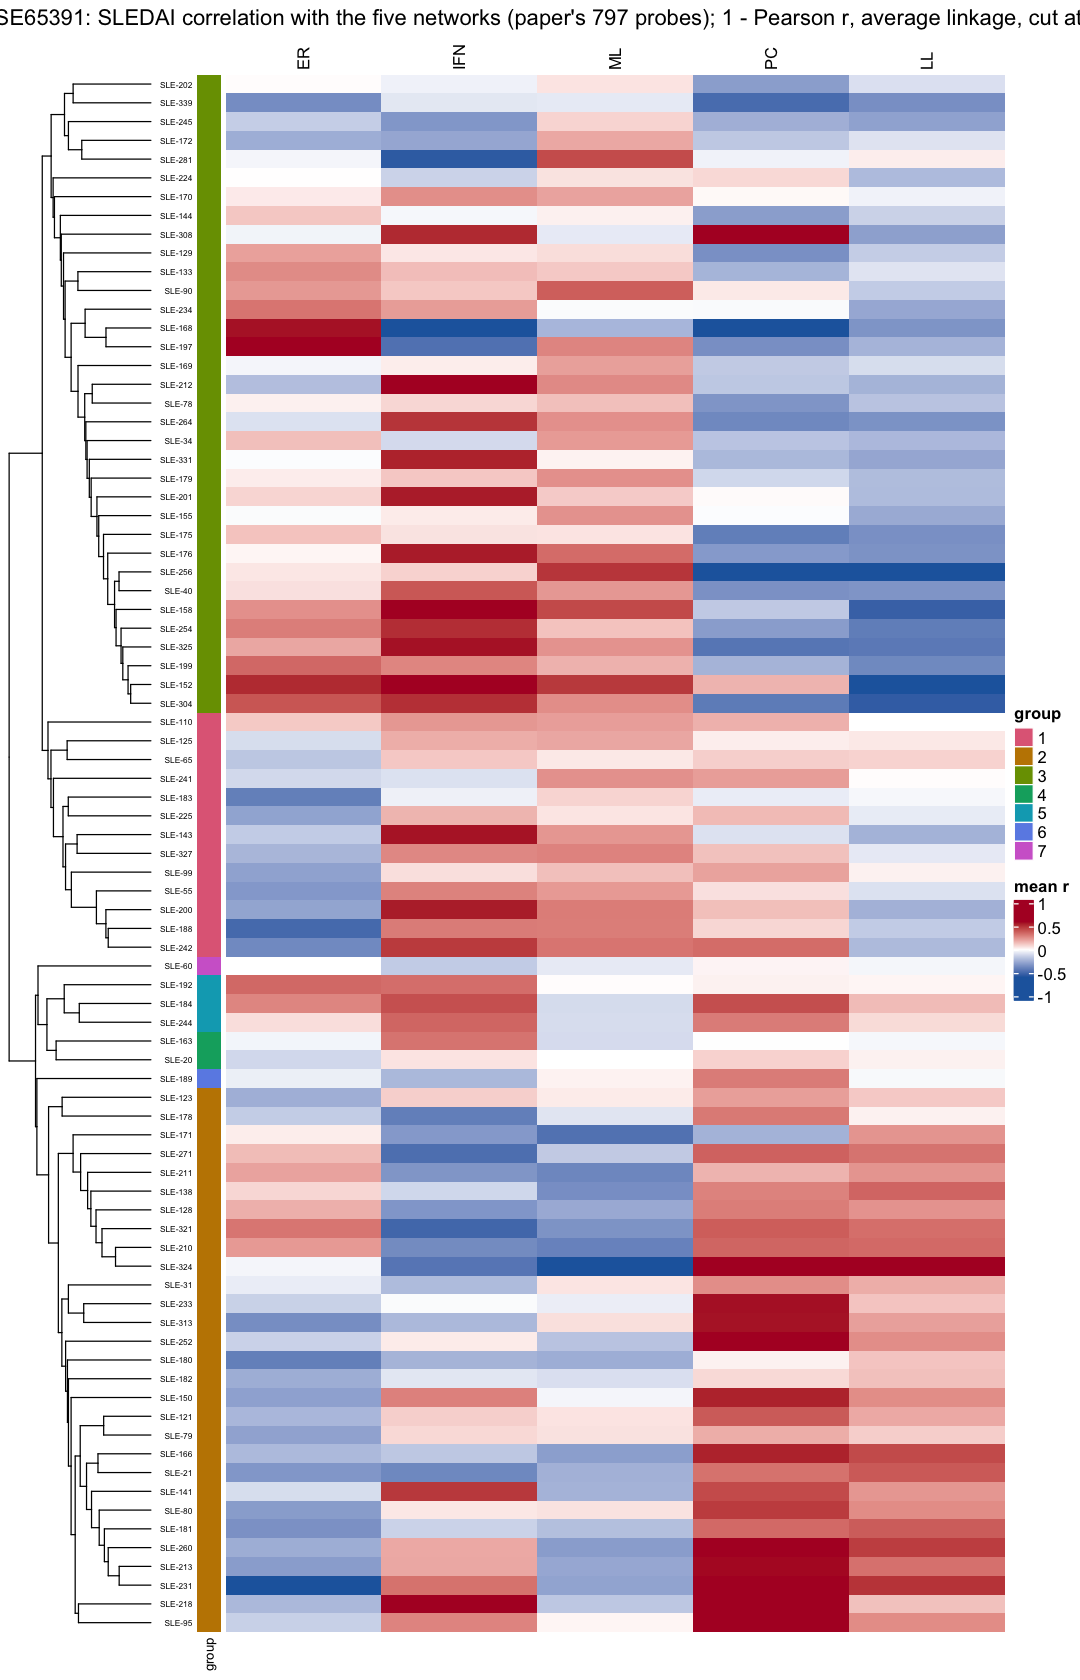

In [3]:
figure <- function() {
  g <- factor(groups[rownames(pg$net5)])
  Heatmap(pg$net5, name = "mean r", col = colorRamp2(c(-0.6, 0, 0.6), c("#2166AC", "white", "#B2182B")),
          cluster_rows = hc, cluster_columns = FALSE,
          row_dend_side = "left", row_dend_width = unit(30, "mm"),
          show_row_names = TRUE, row_names_side = "left", row_names_gp = gpar(fontsize = 5),
          column_names_side = "top", column_names_gp = gpar(fontsize = 10),
          left_annotation = rowAnnotation(group = g, col = list(group = setNames(hcl.colors(7, "Dark 3"), levels(g))),
                                          annotation_name_gp = gpar(fontsize = 8)),
          column_title = "GSE65391: SLEDAI correlation with the five networks (paper's 797 probes); 1 - Pearson r, average linkage, cut at 7 as in the paper")
}
options(repr.plot.width = 9, repr.plot.height = 14)
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig("GSE65391", "06e_PG_paper_method.png"), width = 9, height = 14, units = "in", res = 300)
  out <- figure(); if (inherits(out, c("Heatmap", "HeatmapList"))) draw(out)
  if (device == "png") invisible(dev.off())
}

In [4]:
write.csv(data.frame(subject = names(groups), group = groups), art("GSE65391", "pg_paper_groups.csv"), row.names = FALSE)